In [1]:
import numpy as np
from experiments.resnet_parameter_corr_between_worker import load_grad_files
import torch
from torch.nn.functional import l1_loss
import matplotlib.pyplot as plt

In [2]:
train_attempt_count, worker_count, round_count, epoch_count, batch_count = 6, 2, 2, 30, 17
# train_attempt_count, worker_count, round_count, epoch_count, batch_count = 6, 2, 1, 2, 5

path_to_files = [f"exp_data/gradients_resnet/gradients_resnet_t{i}/"
                 for i in range(train_attempt_count)]

with open(path_to_files[-1] + f"_grad_namings.txt", "rb") as f:
    layer_names = f.read().decode("utf-8").replace("\r", '').split("\n")[:-1]

time_steps = np.array(np.meshgrid(range(round_count), range(epoch_count))).T.reshape(-1, 2)

In [3]:
base_model_dict = torch.load('exp_data/resnet18_svhn.pth', map_location='cpu')
base_model_dict = {k.replace('model.', ''): v.ravel().to('cuda')
                                for k, v in base_model_dict.items() if
                                k.replace('model.', '') in layer_names}

temp = {k: v.clone() for k, v in base_model_dict.items()}
base_model_dict = [base_model_dict, temp]

# worker_id, {layer_name}, element_id
train_attempt_model_dict = [
    {k: v.clone() for k, v in m_dict.items()}
    for m_dict in base_model_dict]

In [4]:
def get_model_similarity(base_model_dict, train_attempt_model_dict):
    mse_loss_per_w=[0,0]
    perc_layer=[0,0]
    total_param_count = sum([torch.numel(base_model_dict[0][k]) for k in layer_names])
    # print('simil, param_sum, simil/param_sum, layer_p_count')
    for i in range(worker_count):
        error_loss = 0
        error_loss_perc = 0
        for k in layer_names:
            base_grad = base_model_dict[i][k]
            attempt_grad = train_attempt_model_dict[i][k]
            similarity = l1_loss(base_grad, attempt_grad, reduction='sum')
            simil = similarity.item()
            error_loss += simil/total_param_count

            param_sum=torch.sum(torch.abs(base_grad)).item()
            error_loss_perc += (simil/param_sum)/total_param_count
            # print(*[f"{l:.3f}" for l in [simil, param_sum, simil/param_sum, len(base_grad)]])
        perc_layer[i]=error_loss_perc
        mse_loss_per_w[i]=error_loss
    return mse_loss_per_w, perc_layer


def get_model_after_epoch(sample_dict, curr_model_state_dict_worker):
    # todo: account for the model aggregation and apply fedavg to worker models
    for k in sample_dict.keys():
        sample_dict[k] = [
            torch.sum(
                torch.tensor(np.array([batch_grad[i] for batch_grad in sample_dict[k]]), device='cuda'),
                dim=0)
            for i in range(worker_count)]

    return [{k: v + sample_dict[k][i] for k, v in curr_model_state_dict_worker[i].items()}
        for i in range(worker_count)]


raw_loss = []
perc_loss=[]
check_attempt = 0
for curr_round, current_epoch in time_steps:
    print(f"\nRound {curr_round}, Epoch {current_epoch} ------------")

    sample_steps_base = np.array(np.meshgrid(
        range(0,1), range(batch_count))).T.reshape(-1, 2)
    # indexing: {layer_name}, sample_id, worker_id, element_id
    sample_dict_base = load_grad_files(sample_steps_base,
            layer_names, path_to_files, curr_round, current_epoch)
    base_model_dict = get_model_after_epoch(sample_dict_base, base_model_dict)

    sample_steps_attempt = np.array(np.meshgrid(
        range(1+check_attempt,2+check_attempt), range(batch_count))).T.reshape(-1, 2)
    # indexing: {layer_name}, sample_id, worker_id, element_id
    sample_dict_attempt = load_grad_files(sample_steps_attempt,
            layer_names, path_to_files, curr_round, current_epoch)
    train_attempt_model_dict = get_model_after_epoch(sample_dict_attempt, train_attempt_model_dict)

    temp1, temp2=get_model_similarity(base_model_dict, train_attempt_model_dict)
    raw_loss.append(temp1)
    perc_loss.append(temp2)
raw_loss=np.array(raw_loss).T
perc_loss = np.array(perc_loss).T


Round 0, Epoch 0 ------------

Round 0, Epoch 1 ------------

Round 0, Epoch 2 ------------

Round 0, Epoch 3 ------------

Round 0, Epoch 4 ------------

Round 0, Epoch 5 ------------

Round 0, Epoch 6 ------------

Round 0, Epoch 7 ------------

Round 0, Epoch 8 ------------

Round 0, Epoch 9 ------------

Round 0, Epoch 10 ------------

Round 0, Epoch 11 ------------

Round 0, Epoch 12 ------------

Round 0, Epoch 13 ------------

Round 0, Epoch 14 ------------

Round 0, Epoch 15 ------------

Round 0, Epoch 16 ------------

Round 0, Epoch 17 ------------

Round 0, Epoch 18 ------------

Round 0, Epoch 19 ------------

Round 0, Epoch 20 ------------

Round 0, Epoch 21 ------------

Round 0, Epoch 22 ------------

Round 0, Epoch 23 ------------

Round 0, Epoch 24 ------------

Round 0, Epoch 25 ------------

Round 0, Epoch 26 ------------

Round 0, Epoch 27 ------------

Round 0, Epoch 28 ------------

Round 0, Epoch 29 ------------

Round 1, Epoch 0 ------------

Round 1, Epoch 1 -

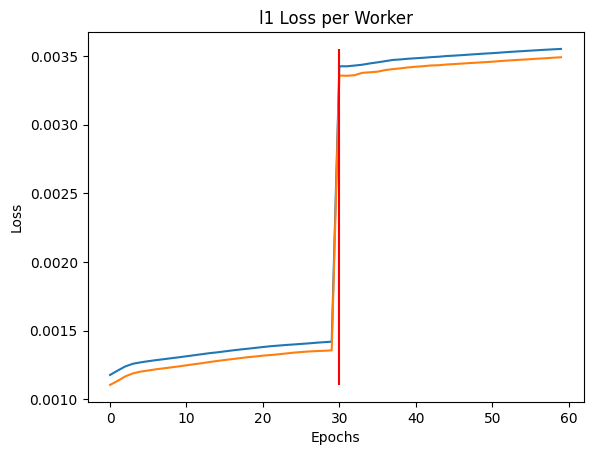

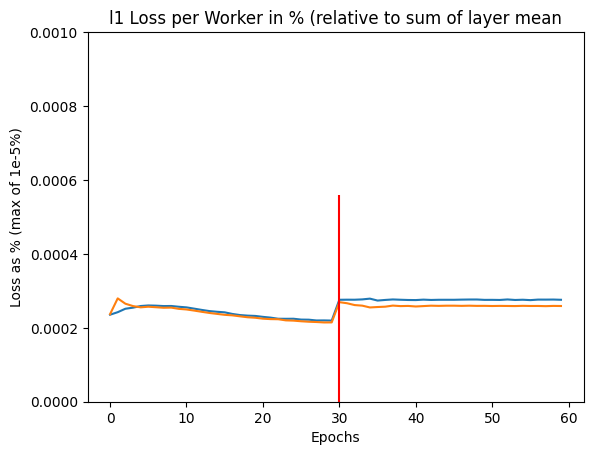

In [14]:
plt.plot(raw_loss[0])
plt.plot(raw_loss[1])
plt.vlines(epoch_count, np.min(raw_loss), np.max(raw_loss), colors='r')
plt.title('l1 Loss per Worker')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

plt.plot(perc_loss[0]*100)
plt.plot(perc_loss[1]*100)
plt.vlines(epoch_count, np.min(perc_loss)*0, np.max(perc_loss)*200, colors='r')
plt.ylim(0,1e-5*100)
plt.title('l1 Loss per Worker in % (relative to sum of layer mean')
plt.xlabel('Epochs')
plt.ylabel('Loss as % (max of 1e-5%)')
plt.show()